In [2]:
import xarray as xr
import time
from os import listdir
from os.path import isfile, join
import numpy as np
from metpy.calc import relative_humidity_from_specific_humidity
from metpy.units import units
import pandas as pd
import packaging as pk
import pint
import warnings
warnings.filterwarnings("ignore")

In [2]:
file_setup = {'All':'/home/stoneda/data/C20C/LBNL/CAM5-1-1degree/All-Hist/est1/v2-0/day/atmos/',
              'Nat':'/home/stoneda/data/C20C/LBNL/CAM5-1-1degree/Nat-Hist/CMIP5-est1/v2-0/day/atmos/'}

lsm = xr.open_dataset('/home/stoneda/data/C20C/LBNL/CAM5-1-1degree/All-Hist/est1/v2-0/fx/atmos/sftlf/run000/sftlf_fx_CAM5-1-1degree_All-Hist_est1_v2-0_run000_000000-000000.nc')


In [3]:
def join_years(var,scen,num_string):
    
    if var == 'ps':
        path = '/home/stoneda/data/C20C/LBNL/CAM5-1-1degree/All-Hist/est1/v2-0/mon/atmos/ps/run' + num_string + '/'
        
    else:
        path = file_setup[scen] + var + '/run' + num_string + '/'
        
    files = [f for f in listdir(path) if isfile(join(path, f))]

    da_list = []
    for file in files:

        da = xr.open_dataset(path+file)[var].sel(lat=slice(20,71), lon=slice(223,255)).where(lsm.sftlf > 0)
        da['time'] = da.indexes['time'].to_datetimeindex()

        da_list.append(da)

    full_da = xr.concat(da_list,'time')
    full_da = full_da.sortby('time')
        
    return(full_da)
    

In [4]:
def create_input_ds(scen,num_string):
    
    pr_da = join_years('pr',scen,num_string).drop('height')
    uas_da = join_years('uas',scen,num_string).drop('height')
    vas_da = join_years('vas',scen,num_string).drop('height')
    tasmax_da = join_years('tasmax',scen,num_string).drop('height')
    huss_da = join_years('huss',scen,num_string).drop('height')
    ps_da = join_years('ps',scen,num_string).drop('height')
    ps_da = ps_da.mean('time')

    # tasmax K to C
    tasmax_da = tasmax_da - 273.15

    # precip kg/m2/s to mm/hr
    pr_da = pr_da*(60*60*24)
        
    # wind m/s to km/h
    wind_da = np.sqrt(uas_da**2 + vas_da**2)
    wind_da = (wind_da * 60 * 60)/1000
    wind_da = wind_da.rename('wind')

    # rel. humidity from pressure, tasmax, specific humidity
    tasmax_da = tasmax_da.assign_attrs(units='degC')
    huss_da = huss_da.assign_attrs(units='kg/kg')
    ps_da = ps_da.assign_attrs(units='Pa')

    rh = relative_humidity_from_specific_humidity(ps_da, tasmax_da, huss_da).to('percent')

    # create dataset
    FWI_inputs = xr.merge([tasmax_da, pr_da, wind_da])
    FWI_inputs['rh'] = (['time','height','lat','lon'],rh)

    FWI_inputs.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/inputs/FWI_inputs_'+scen+'_run'+num_string+'_1959-2018.nc')
    
    

In [27]:
'''
Create FWI input netcdf for each ensemble member
'''

scen = 'All'
all_runs = [i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)]

print(scen)
print(all_runs)
for num in all_runs: 
    print(num)
    t0 = time.time()
    num_string = '0' + str(num) if num > 9 else '00' + str(num)                                                             
    if num == 100: 
        num_string = '100'  

    create_input_ds(scen, num_string)

    t1 = time.time()
    total = t1-t0
    print(total)



scen = 'Nat'
nat_runs = [i for i in range(1,11)] + [i for i in range(36,51)] + [i for i in range(61,71)] + [i for i in range(86,96)] + [i for i in range(97,101)]

print(scen)
print(nat_runs)
for num in nat_runs: 
    print(num)
    t0 = time.time()
    num_string = '0' + str(num) if num > 9 else '00' + str(num)                                                             
    if num == 100: 
        num_string = '100'  

    create_input_ds(scen, num_string)

    t1 = time.time()
    total = t1-t0
    print(total)




111.13093733787537


"\nfor num in nat_runs:  \n    t0 = time.time()\n    num_string = '0' + str(num) if num > 9 else '00' + str(num)                                                             \n    if num == 100: \n        num_string = '100'  \n\n    create_input_ds(scen, num_string)\n\n    t1 = time.time()\n    total = t1-t0\n    print(total)\n\n    break\n"

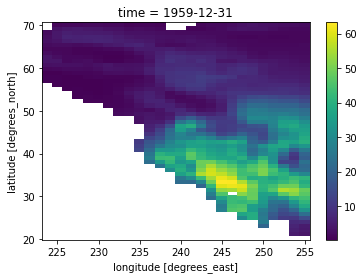

In [21]:
ERA5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/FWI_6month_fire_season_ERA5_resolution.nc')
cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')

ERA5 = ERA5.coarsen(latitude=5,longitude=5,boundary='pad').mean()
ERA5 = ERA5.interp(longitude=cam5.longitude, latitude=cam5.latitude, method="linear")
ERA5 = ERA5.where(~cam5.isnull())

ERA5.isel(time=0).plot()

In [23]:
ERA5.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')